# 🚧 PRF 2025 — Análise de Acidentes com Pandas e Matplotlib

Este notebook adapta os **mesmos tipos de gráficos e a mesma lógica visual** do arquivo de referência `graficos12.ipynb` para o projeto de acidentes da PRF em 2025.

O objetivo é usar a base real do projeto para praticar **Pandas, NumPy e Matplotlib**, mantendo os cinco primeiros gráficos do código fornecido: histograma, densidade e três variações de dispersão.

> **Nota acadêmica:** a atividade original orienta que a entrega oficial seja construída no Excel/Google Sheets. Este notebook é uma **extensão paralela de estudo e portfólio em Python**, sem substituir a entrega exigida pelo professor.

## 1. Importação das bibliotecas

As bibliotecas abaixo seguem a estrutura do código original. O `Pandas` será responsável pela leitura e transformação dos dados; o `NumPy` por cálculos numéricos; e o `Matplotlib` pelos gráficos. O `Seaborn` permanece importado para manter compatibilidade com o material de referência, embora os gráficos principais sejam construídos com Matplotlib/Pandas.

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Exibe os gráficos dentro do notebook
%matplotlib inline

# Configuração geral apenas para melhorar a leitura dos gráficos
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Leitura da base do projeto

A base usada é o Excel trabalhado no projeto PRF 2025. A aba principal contém os registros individuais de acidentes e também as colunas auxiliares construídas durante a atividade.

In [2]:
# Caminhos do projeto
PASTA_PROJETO = Path("..") if Path.cwd().name == "notebooks" else Path(".")
ARQUIVO = PASTA_PROJETO / "dados" / "dados_abertos_prf_2025.xlsx"
PASTA_GRAFICOS = PASTA_PROJETO / "graficos"
PASTA_GRAFICOS.mkdir(exist_ok=True)

# Nome exato da aba da base no Excel
ABA_DADOS = "dados_abertos_prf-datatran2025 "

# Leitura da planilha
# openpyxl é o mecanismo usado pelo Pandas para arquivos .xlsx
df = pd.read_excel(ARQUIVO, sheet_name=ABA_DADOS, engine="openpyxl")

print("Arquivo carregado:", ARQUIVO)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
df.head()

Arquivo carregado: ..\dados\dados_abertos_prf_2025.xlsx
Linhas: 72529
Colunas: 32


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,Total_de_vitimas,Acidentes_Fatais
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225.0,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,...,1,1,2,-23.485868,-46.540753,SPRF-SP,DEL01-SP,UOP01-DEL01-SP,1,0
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,546.2,PENAFORTE,Pista esburacada,Colisão frontal,...,4,1,6,-7.812288,-39.083333,SPRF-CE,DEL05-CE,UOP03-DEL05-CE,2,1
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,88.2,CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,...,0,3,2,-23.182565,-50.637228,SPRF-PR,DEL07-PR,UOP05-DEL07-PR,3,0
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74.0,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,0,1,2,-25.365177,-49.042230,SPRF-PR,DEL01-PR,UOP02-DEL01-PR,1,0
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471.0,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,...,2,2,4,-16.468013,-43.431213,SPRF-MG,DEL12-MG,UOP01-DEL12-MG,2,0


## 3. Preparação e validação dos dados

O código original cria uma variável binária chamada `acidente_fatal`. No nosso projeto, a planilha já possui `Acidentes_Fatais`, mas vamos recriar a coluna com a mesma lógica do código fornecido: **1 quando `mortos > 0` e 0 caso contrário**.

Também serão criadas colunas auxiliares de data, mês e hora para os gráficos temporais.

In [3]:
# Mantém a lógica do código original: 1 = acidente fatal; 0 = não fatal
df["acidente_fatal"] = (df["mortos"] > 0).astype(int)

# Validação: a coluna criada deve coincidir com a coluna auxiliar já existente no projeto
if "Acidentes_Fatais" in df.columns:
    divergencias = (df["acidente_fatal"] != df["Acidentes_Fatais"]).sum()
    print("Divergências entre as duas colunas de acidente fatal:", divergencias)

# Subconjunto somente com acidentes fatais
fatal = df[df["acidente_fatal"] == 1].copy()

# Conversão e criação de variáveis temporais
df["data"] = pd.to_datetime(df["data_inversa"], errors="coerce")
df["mes"] = df["data"].dt.month

# A coluna horario vem do Excel como objeto datetime.time.
# Esta função extrai somente a hora de maneira segura.
def extrair_hora(valor):
    if pd.isna(valor):
        return np.nan
    if hasattr(valor, "hour"):
        return valor.hour
    convertido = pd.to_datetime(str(valor), format="%H:%M:%S", errors="coerce")
    return convertido.hour if not pd.isna(convertido) else np.nan

df["hora_num"] = df["horario"].apply(extrair_hora)

# Nomes dos meses para melhorar os eixos dos gráficos
nomes_meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

print("Total de acidentes fatais:", fatal.shape[0])

Divergências entre as duas colunas de acidente fatal: 0
Total de acidentes fatais: 5210


## 4. Indicadores globais do projeto

Antes dos gráficos, validamos os principais números usados na análise. Isso ajuda a garantir que o Pandas está trabalhando com a mesma base consolidada no Excel.

In [4]:
# Cálculo dos KPIs globais
kpi_total_acidentes = df["id"].count()
kpi_total_mortos = df["mortos"].sum()
kpi_total_feridos = df["feridos_leves"].sum() + df["feridos_graves"].sum()
kpi_total_vitimas = df["Total_de_vitimas"].sum()
kpi_acidentes_fatais = df["acidente_fatal"].sum()
kpi_percentual_fatais = kpi_acidentes_fatais / kpi_total_acidentes * 100
kpi_letalidade = kpi_total_mortos / kpi_total_vitimas * 100

print(f"Total de acidentes: {kpi_total_acidentes:,}".replace(",", "."))
print(f"Total de mortos: {kpi_total_mortos:,}".replace(",", "."))
print(f"Total de feridos: {kpi_total_feridos:,}".replace(",", "."))
print(f"Total de vítimas: {kpi_total_vitimas:,}".replace(",", "."))
print(f"Acidentes fatais: {kpi_acidentes_fatais:,}".replace(",", "."))
print(f"% de acidentes fatais: {kpi_percentual_fatais:.2f}%")
print(f"Taxa de letalidade operacional: {kpi_letalidade:.2f}%")

Total de acidentes: 72.529
Total de mortos: 6.043
Total de feridos: 83.550
Total de vítimas: 89.593
Acidentes fatais: 5.210
% de acidentes fatais: 7.18%
Taxa de letalidade operacional: 6.74%


# 📊 Gráfico 1 — Histograma de mortos por acidente fatal

**Mesmo tipo de gráfico do código original:** `plt.hist()`.

### O que ele mostra
O histograma apresenta a distribuição da quantidade de mortos **dentro dos acidentes que tiveram pelo menos um óbito**. Ele ajuda a perceber se os acidentes fatais normalmente concentram uma morte ou se há grande frequência de eventos com múltiplas mortes.

,mortos,quantidade_acidentes,percentual
0,1,4632,88.9
1,2,434,8.3
2,3,93,1.8
3,4,28,0.5
4,5,13,0.2
5,6,3,0.1
6,7,2,0.0
7,9,2,0.0
8,10,1,0.0
9,11,1,0.0


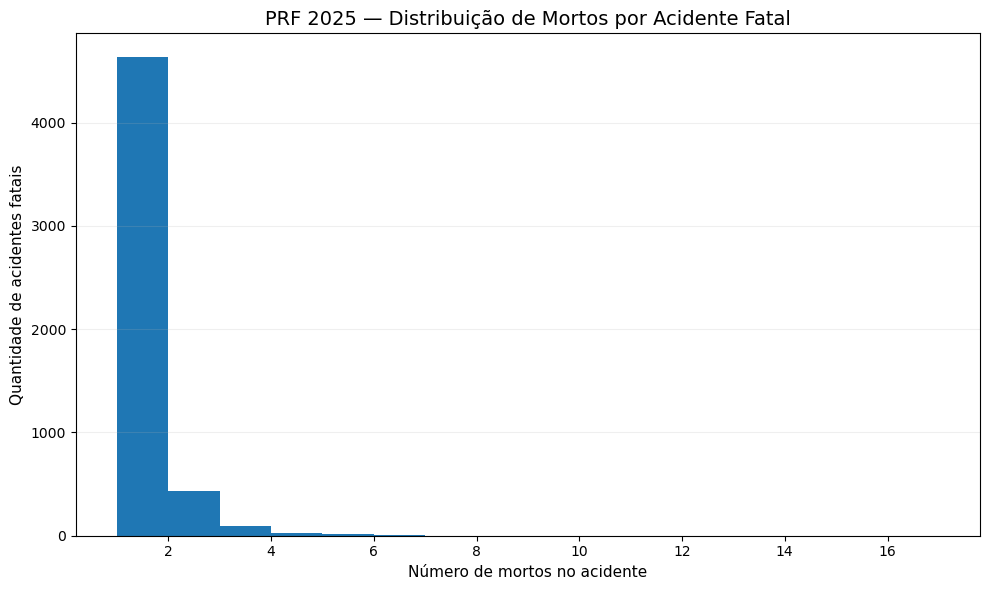

📌 Leitura: 4632 dos 5210 acidentes fatais tiveram exatamente 1 morte (88.9%).


In [5]:
# Tabela auxiliar: quantidade de acidentes para cada número de mortos
tabela = fatal["mortos"].value_counts().sort_index().reset_index()
tabela.columns = ["mortos", "quantidade_acidentes"]
tabela["percentual"] = (
    tabela["quantidade_acidentes"] / tabela["quantidade_acidentes"].sum() * 100
).round(1)

display(tabela)

# Histograma - mesma estrutura do código original
plt.figure(figsize=(10, 6))
plt.hist(fatal["mortos"], bins=range(1, fatal["mortos"].max() + 2))
plt.title("PRF 2025 — Distribuição de Mortos por Acidente Fatal")
plt.xlabel("Número de mortos no acidente")
plt.ylabel("Quantidade de acidentes fatais")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "01_histograma_mortos.png", dpi=180, bbox_inches="tight")
plt.show()

um_morto = tabela.loc[tabela["mortos"] == 1, "quantidade_acidentes"].iloc[0]
print(f"📌 Leitura: {um_morto} dos {len(fatal)} acidentes fatais tiveram exatamente 1 morte ({um_morto/len(fatal)*100:.1f}%).")

# 📈 Gráfico 2 — Densidade de pessoas: acidentes fatais x não fatais

**Mesmo tipo de gráfico do código original:** `Series.plot(kind="density")`.

### O que ele mostra
Compara a distribuição do número de pessoas envolvidas nos acidentes fatais e não fatais. Para impedir que poucos acidentes extremos distorçam a visualização, mantemos o limite superior de 15 pessoas, exatamente como na lógica do material fornecido.

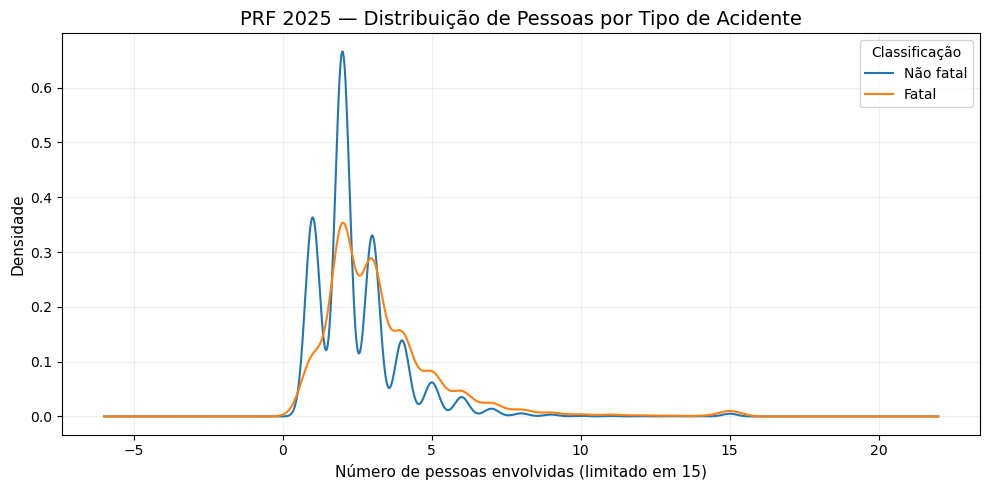

📌 Leitura: acidentes não fatais têm média de 2.53 pessoas; acidentes fatais, 3.46 pessoas.


In [6]:
# Gráfico de densidade
plt.figure(figsize=(10, 5))

for classe, nome in [(0, "Não fatal"), (1, "Fatal")]:
    dados = df.loc[df["acidente_fatal"] == classe, "pessoas"].dropna().clip(upper=15)

    # Para o cálculo de densidade ficar rápido no VS Code, usamos no máximo
    # 10.000 observações por classe. O tipo de gráfico e a interpretação permanecem iguais.
    if len(dados) > 10000:
        dados = dados.sample(10000, random_state=42)

    dados.plot(kind="density", label=nome)

plt.title("PRF 2025 — Distribuição de Pessoas por Tipo de Acidente")
plt.xlabel("Número de pessoas envolvidas (limitado em 15)")
plt.ylabel("Densidade")
plt.legend(title="Classificação")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "02_densidade_pessoas.png", dpi=180, bbox_inches="tight")
plt.show()

media_nao_fatal = df.loc[df["acidente_fatal"] == 0, "pessoas"].mean()
media_fatal = df.loc[df["acidente_fatal"] == 1, "pessoas"].mean()
print(f"📌 Leitura: acidentes não fatais têm média de {media_nao_fatal:.2f} pessoas; acidentes fatais, {media_fatal:.2f} pessoas.")

# 🔹 Gráfico 3 — Dispersão entre veículos e pessoas

**Mesmo tipo de gráfico do código original:** `plt.scatter()`.

### O que ele mostra
Cada ponto representa um acidente da amostra. O eixo X mostra o número de veículos e o eixo Y o número de pessoas envolvidas. O objetivo é observar visualmente se acidentes com mais veículos também tendem a envolver mais pessoas.

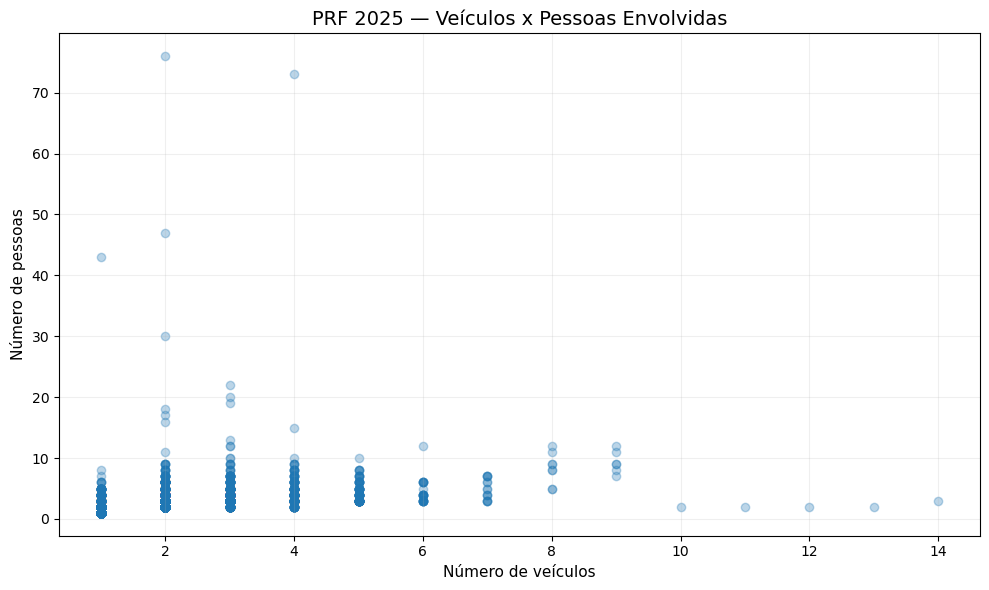

📌 Leitura: a correlação linear entre veículos e pessoas é 0.395. Existe associação positiva, mas ela não implica causalidade.


In [7]:
# Amostra de 5.000 registros para manter o gráfico legível
amostra = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(amostra["veiculos"], amostra["pessoas"], alpha=0.3)
plt.title("PRF 2025 — Veículos x Pessoas Envolvidas")
plt.xlabel("Número de veículos")
plt.ylabel("Número de pessoas")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "03_dispersao_veiculos_pessoas.png", dpi=180, bbox_inches="tight")
plt.show()

correlacao = df[["veiculos", "pessoas"]].corr().iloc[0, 1]
print(f"📌 Leitura: a correlação linear entre veículos e pessoas é {correlacao:.3f}. Existe associação positiva, mas ela não implica causalidade.")

# 📐 Gráfico 4 — Dispersão com linha de tendência

**Mesmo gráfico adicional do código original:** dispersão com uma reta obtida por `np.polyfit()`.

### O que ele mostra
Mantém os mesmos pontos do gráfico anterior e acrescenta uma linha de tendência linear. A linha resume a direção média da relação entre quantidade de veículos e pessoas envolvidas.

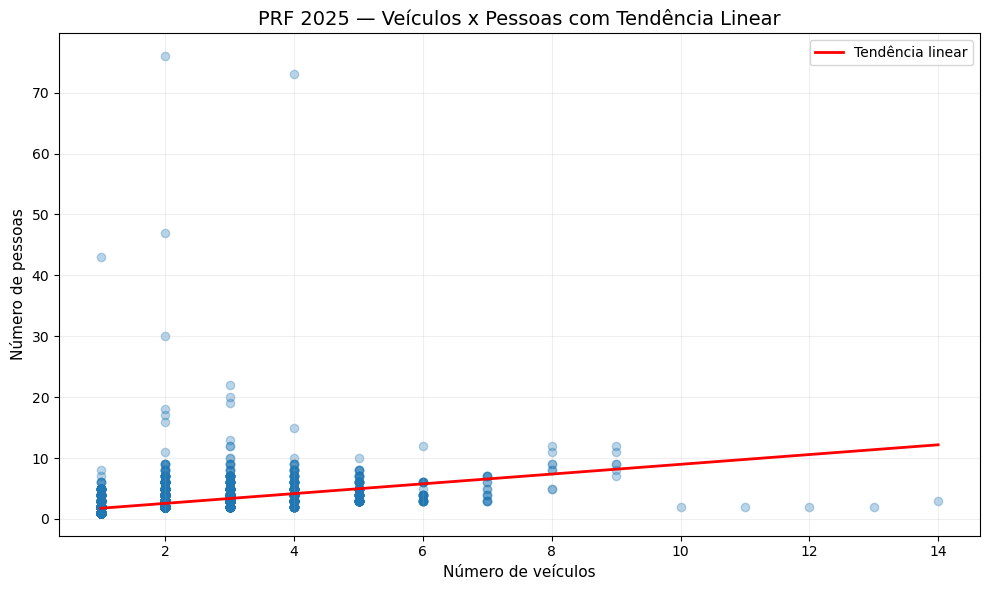

📌 Leitura: na amostra, a inclinação da reta é 0.80. A linha resume associação média e não deve ser interpretada como efeito causal.


In [9]:
# Mesma amostra e mesma lógica do código fornecido
amostra = df.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(amostra["veiculos"], amostra["pessoas"], alpha=0.3)

# Ajuste de uma reta: y = b0 + b1*x
b1, b0 = np.polyfit(amostra["veiculos"], amostra["pessoas"], 1)
x_linha = np.linspace(amostra["veiculos"].min(), amostra["veiculos"].max(), 100)
plt.plot(x_linha, b0 + b1 * x_linha, color="red", linewidth=2, label="Tendência linear")

plt.title("PRF 2025 — Veículos x Pessoas com Tendência Linear")
plt.xlabel("Número de veículos")
plt.ylabel("Número de pessoas")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "04_dispersao_regressao.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"📌 Leitura: na amostra, a inclinação da reta é {b1:.2f}. A linha resume associação média e não deve ser interpretada como efeito causal.")

# 🟢 Gráfico 5 — Dispersão com legenda de fatalidade

**Mesmo tipo do código original:** dois grupos desenhados com `plt.scatter()` e legenda.

### O que ele mostra
Separa os acidentes em **fatais** e **não fatais** dentro do espaço veículos × pessoas. Isso permite verificar se os acidentes fatais aparecem apenas em valores extremos ou também em regiões comuns do conjunto de dados.

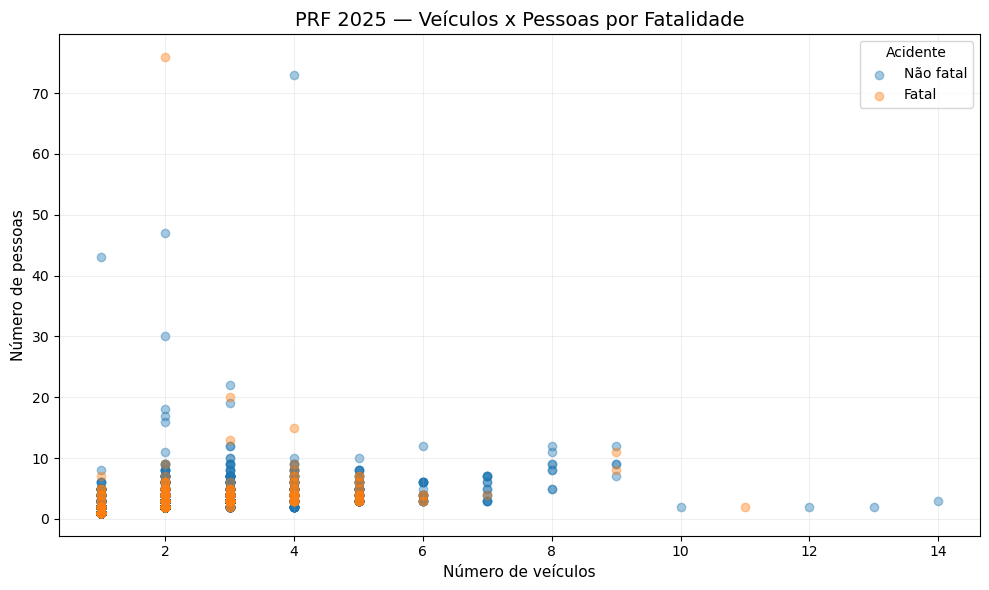

📌 Leitura: os dois grupos se sobrepõem em grande parte. Portanto, veículos e pessoas isoladamente não explicam a fatalidade do acidente.


In [10]:
# Dispersão com legendas
amostra = df.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))

for classe, nome in [(0, "Não fatal"), (1, "Fatal")]:
    grupo = amostra[amostra["acidente_fatal"] == classe]
    plt.scatter(grupo["veiculos"], grupo["pessoas"], alpha=0.4, label=nome)

plt.title("PRF 2025 — Veículos x Pessoas por Fatalidade")
plt.xlabel("Número de veículos")
plt.ylabel("Número de pessoas")
plt.legend(title="Acidente")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "05_dispersao_fatalidade.png", dpi=180, bbox_inches="tight")
plt.show()

print("📌 Leitura: os dois grupos se sobrepõem em grande parte. Portanto, veículos e pessoas isoladamente não explicam a fatalidade do acidente.")

# ✅ Conclusões gerais

Os cinco gráficos preservados mantêm os **mesmos modelos estatísticos e visuais** do notebook fornecido e foram adaptados para a base consolidada da PRF 2025.

Principais achados da execução:

- A base possui **72.529 acidentes**.
- Foram identificados **5.210 acidentes fatais**, equivalentes a aproximadamente **7,18%** das ocorrências.
- Houve **6.043 mortes** e **89.593 vítimas**, resultando em taxa de letalidade operacional de aproximadamente **6,74%**.
- A maioria dos acidentes fatais registra **uma única morte**, embora existam eventos de múltiplas vítimas fatais.
- Os gráficos de dispersão permitem comparar a relação entre veículos e pessoas, observar a linha de tendência e distinguir acidentes fatais dos não fatais.

> Estes resultados são descritivos. Associação visual ou correlação estatística não prova causalidade.


## 💾 Arquivos gerados

Ao executar o notebook, cada visualização é salva automaticamente na pasta `graficos/` em formato PNG. Assim, os gráficos podem ser reutilizados no README, no GitHub ou em uma apresentação.